A neural image recovery of the temperature structure of HD163296
---


In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os, sys
import matplotlib
from pathlib import Path
from ruamel.yaml import YAML
from tqdm.auto import tqdm
from gofish import imagecube
from mpl_toolkits.axes_grid1 import make_axes_locatable
# import emcee, corner
from collections import OrderedDict
import tensorboardX
from flax.training import checkpoints

os.environ['CUDA_VISIBLE_DEVICES'] = '1,2'

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk, inference, network
from network import shard_with_padding, shard
from consts import *

2025-07-25 15:13:34.623655: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
def render_cube(ray_coords, pixel_area, disk_params, nd_co, temperature, velocity_az, bbox, freqs, nu0, obs_dir, molecular_table):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)

    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)

    # Load molecular data from disk_params
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=molecular_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(
        energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    n_up, n_dn = line_rte.n_up_down(
        gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    alpha_tot = line_rte.alpha_total_co(disk_params['v_turb'], gas_t)

    print(f'computing pinhole spectral cube for a total of {freqs.size} frequencies')
    images = line_rte.compute_spectral_cube_pmap(
        shard_with_padding(freqs), gas_v, alpha_tot, n_up, n_dn,
        a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
    )
    images = np.nan_to_num(images).reshape(-1, *ray_coords.shape[:2])[:freqs.size]
    return images

def intensity_to_nchw(intensity, vmin=None, vmax=None, cmap='viridis', gamma=0.5):
    cm = plt.get_cmap(cmap)
    if vmin is None: vmin = np.min(intensity)
    if vmax is None: vmax = np.max(intensity)
    norm_images = np.flip(( (intensity - vmin) / (vmax - vmin) )**gamma, axis=-2)
    if intensity.ndim == 2:
        nchw_images = np.moveaxis(cm(norm_images)[...,:3], (0, 1, 2), (1, 2, 0))
    elif intensity.ndim == 3:
        nchw_images = np.moveaxis(cm(norm_images)[...,:3], (0, 1, 2, 3), (0, 2, 3, 1))
    return nchw_images

In [4]:
fov_as = 14.0   # arcsecs
velocity_range = (2000, 10000) # m/s
vlsr = 5760   # m/s

disk_name = 'HD163296'
data_path = '../data/alma/HD163296_CO_highres_cen.cm.fits'
data_cube = imagecube(data_path, FOV=fov_as, velocity_range=velocity_range)
freqs = data_cube.velocity_to_restframe_frequency(vlsr=vlsr)
velocities = data_cube.velax
data = data_cube.data
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
nu0 = data_cube.nu0
npix = data_cube.nxpix
width_kms = (velocities[-1] - velocities[0]) / 1000.0
delta_v_ms = velocities[1] - velocities[0]
num_freqs = len(freqs)
data_dir = Path(data_path).parent
print('velocity resolution: {} m/s'.format(delta_v_ms))

beam = data_cube.beams_per_pix * sensor.beam(data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa)

velocity resolution: 39.682494279300045 m/s


2025-07-25 15:13:46.802996: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.4.131). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Fiducial model

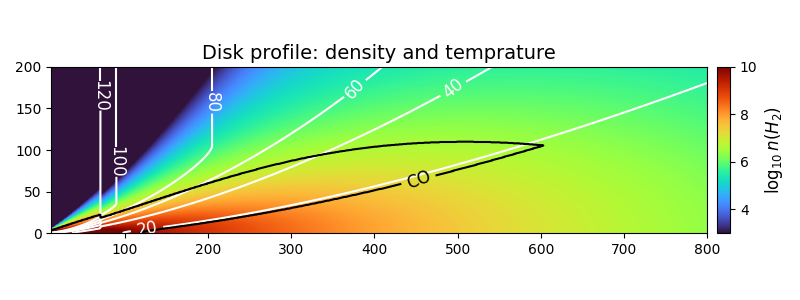

In [5]:
molecular_table = "../molecular_tables/molecule_12c16o.inp"
disk_params = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk_params['r_in'], 800
z_disk, r_disk = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution), 
    jnp.linspace(r_min, r_max, resolution), 
    indexing='ij'
)
# Bounding box for interpolations
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])

# Gas density, temperature and velocity
temperature = parametric_disk.temperature_profile(z_disk, r_disk, disk_params)
nd_h2 = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature,
    disk_params['gamma'],
    disk_params['r_in'],
    10 ** disk_params['log_r_c'],
    disk_params['M_gas'],
    disk_params['M_star'],
    disk_params['m_mol']
)
velocity_az = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2, 
    temperature, 
    disk_params
)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
sigma_h2 = N_h2 * m_h

# Compute the relative abundance of co
abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk_params)
nd_co = abundance_co * nd_h2

%matplotlib widget
fig, ax = plt.subplots(figsize=(8,3))
visualization.plot_disk_profile(ax, r_disk, z_disk, temperature, nd_h2, abundance_co, disk_params['co_abundance'])
# cp = ax.contour(r_disk, z_disk, sigma_h2, levels=[0.01, 0.1], colors='black', linestyles='dotted')
plt.tight_layout()

In [6]:
projection = sensor.PinholeProjection(
    name=disk_name,
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs
)

fov_rad = fov_as * arcsec
fov = 2 * projection.distance * pc * np.tan(fov_rad / 2.0)
pixel_area = (fov / npix) ** 2

ray_coords, obs_dir= sensor.pinhole_disk_projection(
    projection.x_sky,
    projection.y_sky,
    projection.distance,
    projection.nray,
    projection.incl,
    projection.phi,
    projection.posang,
    projection.z_width
)

# Render spectral cube and convolve with gaussian beam
images = render_cube(
    ray_coords,
    pixel_area,
    disk_params,
    nd_co,
    temperature,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir,
    molecular_table=molecular_table
)
images_blurred = sensor.fftconvolve_vmap(images, beam)

computing pinhole spectral cube for a total of 115 frequencies


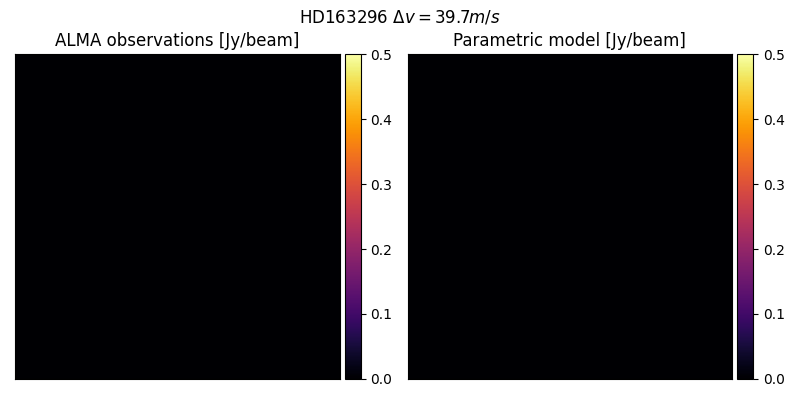

In [44]:
# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(1,2,figsize=(8,4))
fig.suptitle(r'{} $\Delta v = {:2.1f} m/s$'.format(disk_name, delta_v_ms))
titles = [r'ALMA observations [Jy/beam]', r'Parametric model [Jy/beam]']
visualization.animate_movies_synced([data, np.array(images_blurred)], axes, vmin=[0,0], vmax=[0.5]*2, 
                                    titles=titles, cmaps='inferno', fps=5)

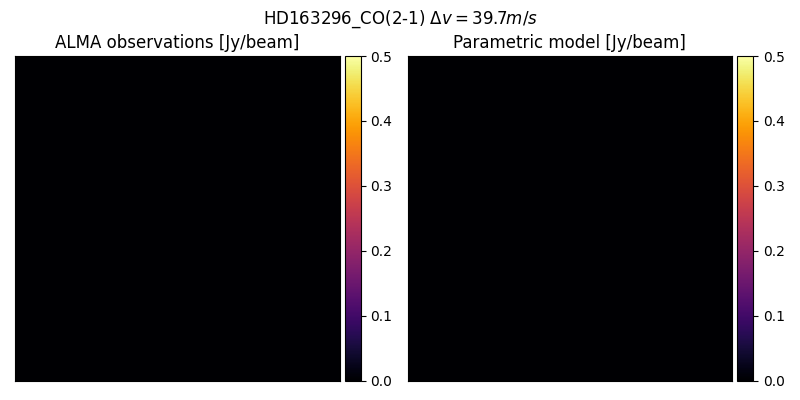

In [6]:
# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(1,2,figsize=(8,4))
fig.suptitle(r'{} $\Delta v = {:2.1f} m/s$'.format(disk_name, delta_v_ms))
titles = [r'ALMA observations [Jy/beam]', r'Parametric model [Jy/beam]']
visualization.animate_movies_synced([data, np.array(images_blurred)], axes, vmin=[0,0], vmax=[0.5]*2, 
                                    titles=titles, cmaps='inferno', fps=5, 
                                    output=data_path.replace('fits', 'parameteric.gif'))

# Neural recovery of the temperature profile

In [7]:
from jax import jit
from functools import partial
import flax
from datetime import datetime

@jax.tree_util.register_pytree_node_class
class NeuralTemperatureDisk(object):
    def __init__(self, z_disk, r_disk, bbox, pixel_area, ray_coords, ray_coords_polar, obs_dir, beam, 
                 energy_levels, radiative_transitions, disk):
        self.z_disk = z_disk
        self.r_disk = r_disk
        self.coords = jnp.stack((z_disk, r_disk), axis=-1).reshape(-1,2)
        self.bbox = bbox
        self.pixel_area = pixel_area
        self.ray_coords = ray_coords
        self.ray_coords_polar = ray_coords_polar
        self.obs_dir = obs_dir
        self.beam = beam
        self.energy_levels = energy_levels
        self.radiative_transitions = radiative_transitions
        self.disk = disk
        self.nu0, self.a_ud, self.b_ud, self.b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions, transition=disk['transition'])
        self.disk_shape = z_disk.shape

    @partial(jit, static_argnums=(0, 2))
    def image_prediction(self, params, temp_fn, freqs):
            disk = self.disk
            temperature = temp_fn({'params': params}, self.coords).reshape(self.disk_shape)
        
            nd_h2 = parametric_disk.number_density_profile(
                self.z_disk, self.r_disk, temperature, disk['gamma'], disk['r_in'], 10**disk['log_r_c'], disk['M_gas'], disk['M_star'], disk['m_mol']
            )
            velocity_az = -parametric_disk.velocity_profile(self.z_disk, self.r_disk, nd_h2, temperature, disk)
            
            # Compute the column integrated density N(h2) (units of 1/cm^2)
            N_h2 = parametric_disk.surface_density(self.z_disk, nd_h2)
            
            # Compute the relative abundance of co
            abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk)
            nd_co = abundance_co * nd_h2
            
            # Interpolate dataset along the ray coordinates
            gas_nd = grid.interpolate_scalar(nd_co, self.ray_coords_polar, self.bbox)
            gas_t  = grid.interpolate_scalar(temperature, self.ray_coords_polar, self.bbox, cval=1e-10)
            gas_v_az = grid.interpolate_scalar(velocity_az, self.ray_coords_polar, self.bbox)
            gas_v = parametric_disk.azimuthal_velocity(self.ray_coords, gas_v_az)
            
            # Einstein coefficient for spontaneous emission from level u to level d
            n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, self.energy_levels, self.radiative_transitions, transition=disk['transition'])
            alpha_tot = line_rte.alpha_total_co(disk['v_turb'], gas_t)
        
            model = jnp.nan_to_num(line_rte.compute_spectral_cube(
                freqs, gas_v, alpha_tot, n_up, n_dn, self.a_ud, self.b_ud, self.b_du, self.ray_coords, self.obs_dir, self.nu0, self.pixel_area
            ))
            model = sensor.fftconvolve_vmap(model, self.beam)
            return model
    
    def tree_flatten(self):
        children = (self.z_disk, self.r_disk, self.bbox, self.pixel_area, self.ray_coords, 
                    self.ray_coords_polar, self.obs_dir, self.beam, self.energy_levels, 
                    self.radiative_transitions, self.sigma, self.disk)
        aux_data = {}
        return (children, aux_data)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children, **aux_data) 


@partial(jit, static_argnums=(4,5))
def loss_fn(params, data, freqs, sigma, image_fn, temp_fn):
    model = image_fn(params, temp_fn, freqs)
    loss = jnp.mean(( (data-model)/sigma )**2)
    return loss
    
@partial(jit, static_argnums=(0, 1))
def gradient_step(loss_fn, image_fn, state, data, freqs, sigma):
    loss, grads = jax.value_and_grad(loss_fn, argnums=(0))(state.params, data, freqs, sigma, image_fn, state.apply_fn)
    grads = jax.lax.pmean(grads, axis_name='batch')
    loss = jax.lax.pmean(loss, axis_name='batch')
    state = state.apply_gradients(grads=grads)
    return loss, state

hparams = dict(
    run_name = 'SGD_with_redshift_val',
    datetime = datetime.now().strftime('%Y-%m-%d.%H:%M:%S'),
    disk_name = disk_name,
    num_iters = 30000,
    posenc_deg = 4,
    sigma = 0.05,        # 5 mJy is ~1% noise level (peak of 0.5Jy)
    seed = 42,
    max_temp = 400.0,
    min_temp = 5.0,
    offset = 0.0,
    batchsize = 10 * jax.device_count(),
    z_max = z_max, 
    r_max = r_max
)


ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=molecular_table)
energy_levels, radiative_transitions = jnp.array(energy_levels), jnp.array(radiative_transitions)
 
neural_temp = NeuralTemperatureDisk(
    z_disk, r_disk, bbox_disk, pixel_area, ray_coords, ray_coords_polar, obs_dir, 
    beam, energy_levels, radiative_transitions, disk_params, 
)

predictor = network.PixelPredictor(
    scale=np.array([hparams['z_max'], hparams['r_max']]), posenc_deg=hparams['posenc_deg'], 
    min_val=hparams['min_temp'], max_val=hparams['max_temp'], offset=hparams['offset']
)
params = predictor.init_params(neural_temp.coords, seed=hparams['seed'])
state = predictor.init_state(params, hparams['num_iters'])

# Replicate state and pmap for multiple gpus
state = flax.jax_utils.replicate(state)
grad_pmap = jax.pmap(gradient_step, axis_name='batch', in_axes=(None, None, 0, 0, 0, None), static_broadcasted_argnums=(0, 1))

In [8]:
log_cadance = 100
ckpt_cadance = 1000
num_test_images = 10

half_point = 58
data_redshift = data[:half_point]
data_blueshift = data[half_point:]
freqs_redshift = freqs[:half_point]
freqs_blueshift = freqs[half_point:]
images_blurred_redshift = images_blurred[:half_point]
images_blurred_blueshift = images_blurred[half_point:]

key = jax.random.key(hparams['seed'])
batch_indices = jax.random.randint(key, (hparams['num_iters'], hparams['batchsize']), minval=0, maxval=half_point)
test_indices = np.arange(0, half_point-1, (half_point-1) // num_test_images)[:num_test_images]

# Initialize logging and checkpoint directories
logdir = Path(data_path).parent.joinpath('recovery/neural_temperature/{}/{}.{}'.format(hparams['disk_name'], hparams['run_name'], hparams['datetime']))
checkpoint_dir = logdir.absolute()
writer = tensorboardX.SummaryWriter(logdir=logdir)

yaml = YAML(typ='safe')
yaml.default_flow_style = False
with open(logdir.joinpath('hparams.yaml'), 'w') as file:
    yaml.dump(hparams, file)
    
# Add some intial logging of data, parametric residuals etc
i_min, i_max = min(data_redshift[test_indices].min(), data_blueshift[test_indices].min()),  max(data_redshift[test_indices].max(), data_blueshift[test_indices].max())
t_min, t_max = temperature.min(), temperature.max()
writer.add_image('temperature/parametric', intensity_to_nchw(temperature, t_min, t_max), global_step=0)
writer.add_images('fluxes/data_redshift', intensity_to_nchw(data_redshift[test_indices], i_min, i_max), global_step=0)
writer.add_images('fluxes/data_blueshift', intensity_to_nchw(data_blueshift[test_indices], i_min, i_max), global_step=0)
writer.add_images('fluxes/parametric_redshift', intensity_to_nchw(images_blurred_redshift[test_indices], i_min, i_max), global_step=0)
writer.add_images('fluxes/parametric_blueshift', intensity_to_nchw(images_blurred_blueshift[test_indices], i_min, i_max), global_step=0)
writer.add_images('fluxes/parametric_residual_redshift', intensity_to_nchw(np.abs(data_redshift[test_indices]-images_blurred_redshift[test_indices]), cmap='inferno'), global_step=0)
writer.add_images('fluxes/parametric_residual_blueshift', intensity_to_nchw(np.abs(data_blueshift[test_indices]-images_blurred_blueshift[test_indices]), cmap='inferno'), global_step=0)

for step, batch in enumerate(tqdm(batch_indices)):
    
    if (step % log_cadance) == 0:
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        current_params = current_state.params
        
        temperature_nn = np.array(predictor.apply({'params': current_params}, neural_temp.coords).reshape(neural_temp.disk_shape))
        redshift_images = np.array(neural_temp.image_prediction(current_params, predictor.apply, freqs_redshift[test_indices]))
        blueshift_images = np.array(neural_temp.image_prediction(current_params, predictor.apply, freqs_blueshift[test_indices]))
        writer.add_image('temperature/neural', intensity_to_nchw(temperature_nn, t_min, t_max), global_step=step)
        writer.add_images('fluxes/neural_redshift', intensity_to_nchw(redshift_images, i_min, i_max), global_step=step)
        writer.add_images('fluxes/neural_blueshift', intensity_to_nchw(blueshift_images, i_min, i_max), global_step=step)
        writer.add_images('fluxes/neural_residual_redshift', intensity_to_nchw(np.abs(data_redshift[test_indices]-redshift_images), cmap='inferno'), global_step=step)
        writer.add_images('fluxes/neural_residual_blueshift', intensity_to_nchw(np.abs(data_blueshift[test_indices]-blueshift_images), cmap='inferno'), global_step=step)
        writer.add_scalar('redshift_datafit/neural', np.mean((data_redshift[test_indices]-redshift_images)**2), global_step=step)
        writer.add_scalar('redshift_datafit/parametric', np.mean((data_redshift[test_indices]-images_blurred_redshift[test_indices])**2), global_step=step)
        writer.add_scalar('blueshift_datafit/neural', np.mean((data_blueshift[test_indices]-blueshift_images)**2), global_step=step)
        writer.add_scalar('blueshift_datafit/parametric', np.mean((data_blueshift[test_indices]-images_blurred_blueshift[test_indices])**2), global_step=step)
                               
    if (step % ckpt_cadance) == 0:
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        checkpoints.save_checkpoint(checkpoint_dir, current_state, step, keep=3)
        
    loss, state = grad_pmap(loss_fn, neural_temp.image_prediction, state, shard(data[batch]), shard(freqs_redshift[batch]), hparams['sigma'])
    writer.add_scalar('log_loss', np.log10(np.mean(loss)), global_step=step)

# Save final state
current_state = jax.device_get(flax.jax_utils.unreplicate(state))
checkpoints.save_checkpoint(checkpoint_dir, current_state, step+1, keep=3)

  0%|          | 0/30000 [00:00<?, ?it/s]

2025-07-25 15:14:54.939271: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %subtract.387 = f64[282,282,100,2]{3,2,1,0} subtract(f64[282,282,100,2]{3,2,1,0} %constant.130, f64[282,282,100,2]{3,2,1,0} %broadcast.386), metadata={op_name="jit(image_prediction)/jit(main)/sub" source_file="/scratch/imaging/projects/protoplanetary/radjax/notebooks/../grid.py" source_line=65}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-07-25 15:15:22.922202: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 28.982987364s
Constant folding an instruction is taking > 1s:

  %

'/scratch/imaging/projects/protoplanetary/radjax/data/alma/recovery/neural_temperature/HD163296/SGD_with_redshift_val.2025-07-25.15:14:31/checkpoint_30000'

In [32]:
batch_indices = jax.random.randint(jax.random.split(key)[0], (hparams['num_iters'], 20000), minval=0, maxval=num_freqs)

In [ ]:
from tqdm.contrib import tzip

for step, batch in tzip(range(30000, 50000), batch_indices):
    
    if (step % log_cadance) == 0:
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        current_params = current_state.params
        
        temperature_nn = np.array(predictor.apply({'params': current_params}, neural_temp.coords).reshape(neural_temp.disk_shape))
        test_images = np.array(neural_temp.image_prediction(current_params, predictor.apply, freqs[test_indices]))
        writer.add_image('temperature/neural', intensity_to_nchw(temperature_nn, t_min, t_max), global_step=step)
        writer.add_images('fluxes/neural', intensity_to_nchw(test_images, i_min, i_max), global_step=step)
        writer.add_images('fluxes/neural_residual', intensity_to_nchw(np.abs(data[test_indices]-test_images), cmap='inferno'), global_step=step)
        writer.add_scalar('test_datafit/neural', np.mean((data[test_indices]-test_images)**2), global_step=step)
        writer.add_scalar('test_datafit/parametric', np.mean((data[test_indices]-images_blurred[test_indices])**2), global_step=step)

                               
    if ((step % ckpt_cadance) == 0) and (step > 30000):
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        checkpoints.save_checkpoint(checkpoint_dir, current_state, step, keep=3)
        
    loss, state = grad_pmap(loss_fn, neural_temp.image_prediction, state, shard(data[batch]), shard(freqs[batch]), hparams['sigma'])
    writer.add_scalar('log_loss', np.log10(np.mean(loss)), global_step=step)

# Save final state
current_state = jax.device_get(flax.jax_utils.unreplicate(state))
checkpoints.save_checkpoint(checkpoint_dir, current_state, step+1, keep=3)

  0%|          | 0/20000 [00:00<?, ?it/s]

# Analyze checkpoint

In [9]:
checkpoint_dir = Path('../data/alma/recovery/neural_temperature/HD163296/SGD_with_redshift_val.2025-07-25.15:14:31/')

with open(checkpoint_dir.joinpath('hparams.yaml'), 'r') as stream:
    hparams = YAML(typ='safe').load(stream)

predictor = network.PixelPredictor(
    scale=np.array([hparams['z_max'], hparams['r_max']]), posenc_deg=hparams['posenc_deg'], 
    min_val=hparams['min_temp'], max_val=hparams['max_temp'], offset=hparams['offset']
)

coords = jnp.stack((z_disk, r_disk), axis=-1).reshape(-1,2)
checkpoint_params = checkpoints.restore_checkpoint(checkpoint_dir, None)['params']
temperature_nn = np.array(predictor.apply({'params': checkpoint_params}, coords).reshape(resolution, resolution))

nd_h2_nn = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature_nn, 
    disk_params['gamma'], 
    disk_params['r_in'], 
    10**disk_params['log_r_c'], 
    disk_params['M_gas'], 
    disk_params['M_star'], 
    disk_params['m_mol']
)
velocity_az_nn = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2, 
    temperature, 
    disk_params
)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2_nn = parametric_disk.surface_density(z_disk, nd_h2_nn)

# Compute the relative abundance of co
abundance_co_nn = parametric_disk.co_abundance_profile(N_h2_nn, temperature_nn, disk_params)
nd_co_nn = abundance_co_nn * nd_h2_nn

sigma_h2_nn = N_h2_nn * m_h

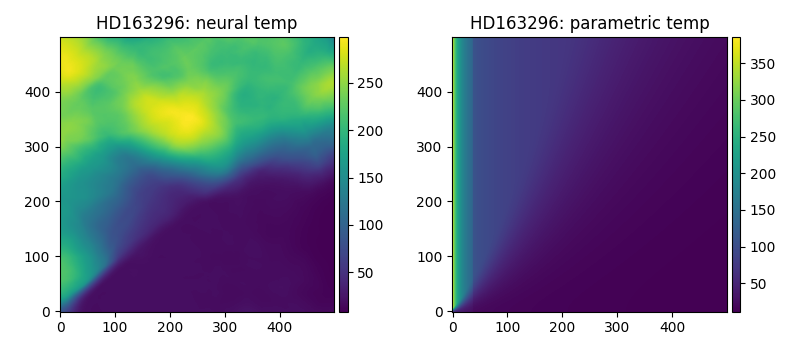

In [10]:
%matplotlib widget
fig, axes = plt.subplots(1, 2, figsize=(8,3.5))
titles = ['{}: neural temp', '{}: parametric temp']
images = [temperature_nn, temperature]
for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, origin='lower')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='3%', pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    ax.set_title(title.format(disk_name))
plt.tight_layout()

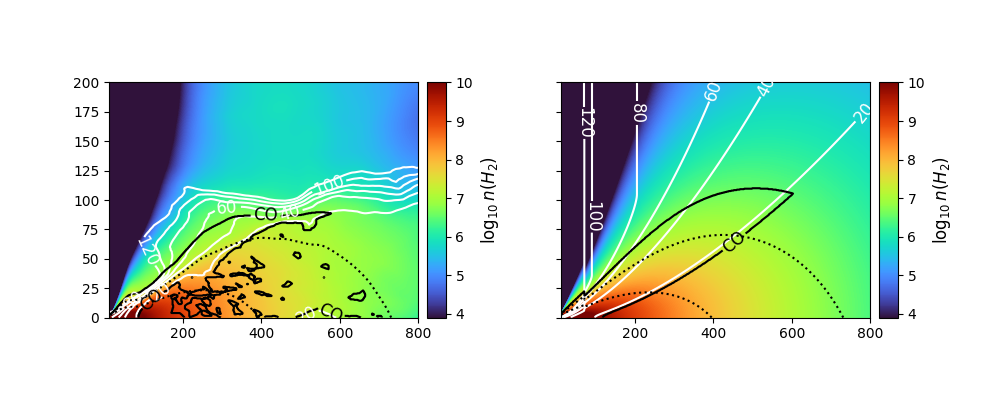

In [11]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2_nn), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature_nn, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co_nn, levels=[disk_params['co_abundance']/2], colors='black')
axes[0].clabel(cp, levels=[disk_params['co_abundance']/2], fmt='CO', inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, sigma_h2_nn, levels=[0.01, 0.1], colors='black', linestyles='dotted')

im = axes[1].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

cp = axes[1].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[1].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[1].contour(r_disk, z_disk, abundance_co, levels=[disk_params['co_abundance']/2], colors='black')
axes[1].clabel(cp, levels=[disk_params['co_abundance']/2], fmt='CO', inline=1, fontsize=12);
cp = axes[1].contour(r_disk, z_disk, sigma_h2, levels=[0.01, 0.1], colors='black', linestyles='dotted')

plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

In [7]:
# Render spectral cube and convolve with gaussian beam
# images = render_cube(ray_coords, pixel_area, disk, nd_co, temperature, -velocity_az, bbox_disk, freqs, nu0)
# images_blurred = sensor.fftconvolve_vmap(images, beam)
images_nn = render_cube(
    ray_coords,
    pixel_area,
    disk_params,
    nd_co_nn,
    temperature_nn,
    -velocity_az_nn,  # note sign convention
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir,
    molecular_table=molecular_table
)
images_blurred_nn = sensor.fftconvolve_vmap(images_nn, beam)

# Save output cube: the header flips the .fits frequency. I guess its because of the way go-fish loads the data.
# from astropy.io import fits
# out_path = checkpoint_dir.joinpath('spectral_cube_iter30000_blurred.fits')
# fits.writeto(out_path, images_blurred_nn.astype('float32'), data_cube.header)
# np.save(checkpoint_dir.joinpath('data_cube_' + hparams['disk_name'] + '.npy'), data)
# np.save(checkpoint_dir.joinpath('recovered_cube_iter30000_blurred.npy'), images_blurred_nn)

computing pinhole spectral cube for a total of 115 frequencies


interactive(children=(IntSlider(value=57, description='frame', max=114), Output()), _dom_classes=('widget-inte…

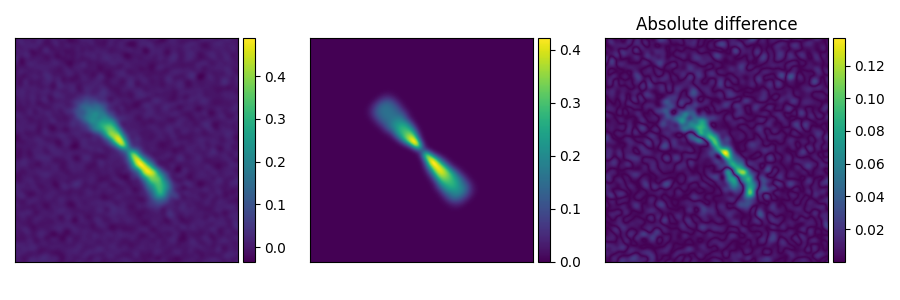

In [55]:
%matplotlib widget
visualization.slider_frame_comparison(data, images_blurred_nn)

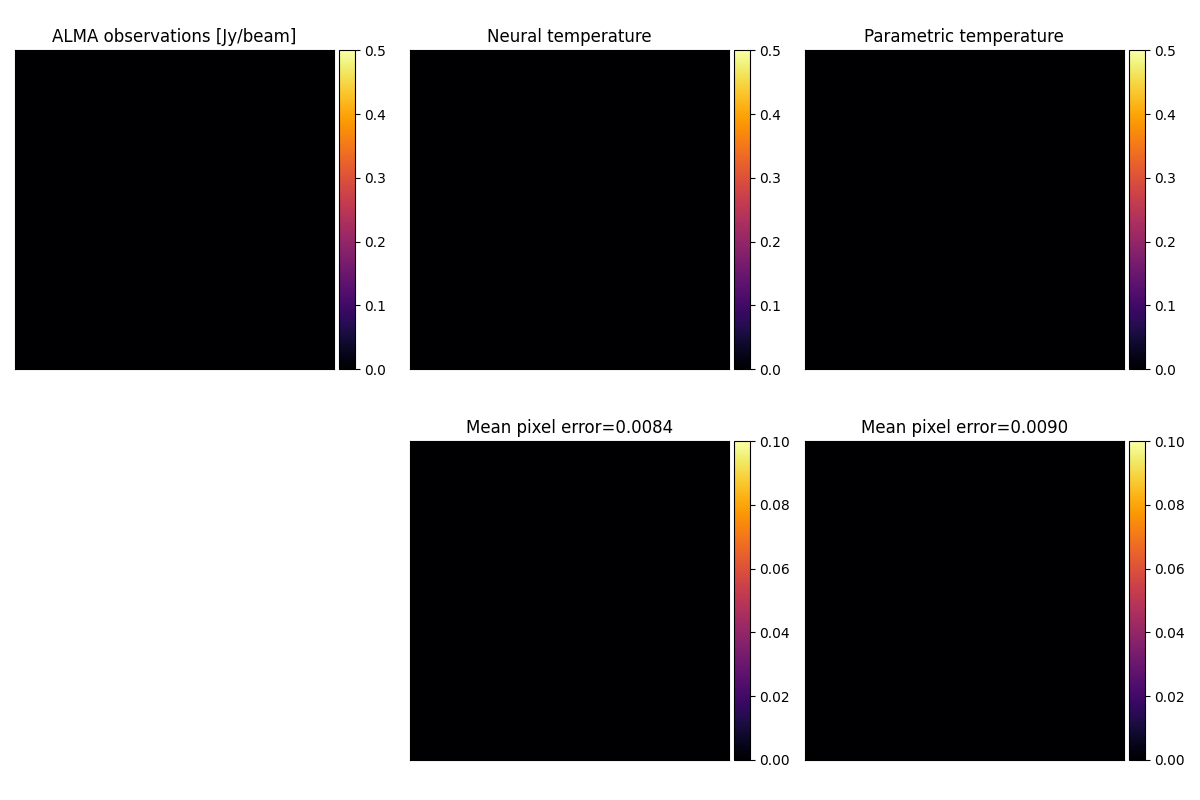

In [8]:
output = checkpoint_dir.joinpath('spectral_cubes_comparison_iter30000.gif')

# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(2,3,figsize=(12,8))
axes[1,0].axis("off")
axes_list = list(axes[0]) + list(axes[1,1:])

data_fit = np.abs(data - images_blurred).mean()
data_fit_nn = np.abs(data - images_blurred_nn).mean()
titles = [r'ALMA observations [Jy/beam]', 'Neural temperature', 'Parametric temperature',
          r'Mean pixel error={:1.4f}'.format(data_fit_nn), r'Mean pixel error={:1.4f}'.format(data_fit)]
movies = [data, np.array(images_blurred_nn), np.array(images_blurred),
         np.abs(data - images_blurred_nn), np.abs(data - images_blurred)]
visualization.animate_movies_synced(
    movies, axes_list, vmin=[0,0,0,0,0,0], vmax=[0.5,0.5,0.5,0.1,0.1], 
    titles=titles, cmaps='inferno', fps=3, writer='ffmpeg', #output=output
)

# $C^{18}O$ Isotopue

In [3]:
fov_as = 14.0   # arcsecs
vlsr = 5750   # m/s
c18o_abundance = 1/557
velocity_range = (3200, 8200) # m/s
disk_name = 'HD163296'

data_path = '../data/alma/HD163296_C18O_lowres.cm.fits'
data_cube = imagecube(data_path, FOV=fov_as, velocity_range=velocity_range)
freqs = data_cube.velocity_to_restframe_frequency(vlsr=vlsr)
velocities = data_cube.velax
data = data_cube.data
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
nu0 = data_cube.nu0
npix = data_cube.nxpix
width_kms = (velocities[-1] - velocities[0]) / 1000.0
delta_v_ms = velocities[1] - velocities[0]
num_freqs = len(freqs)
data_dir = Path(data_path).parent
print('velocity resolution: {} m/s'.format(delta_v_ms))

beam = data_cube.beams_per_pix * sensor.beam(data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa)

velocity resolution: 208.33274993900068 m/s


2025-07-18 17:56:52.753084: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.4.131). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## Neural temperature

computing pinhole spectral cube for a total of 24 frequencies


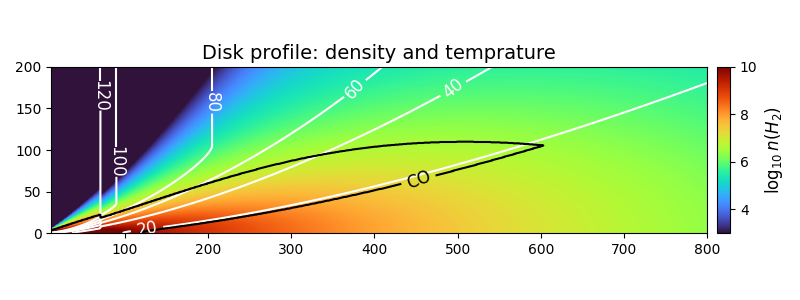

In [4]:
git stat
projection = sensor.PinholeProjection(
    name=disk_name,
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs
)

fov_rad = fov_as * arcsec
fov = 2 * projection.distance * pc * np.tan(fov_rad / 2.0)
pixel_area = (fov / npix) ** 2

ray_coords, obs_dir= sensor.pinhole_disk_projection(
    projection.x_sky,
    projection.y_sky,
    projection.distance,
    projection.nray,
    projection.incl,
    projection.phi,
    projection.posang,
    projection.z_width
)

# Render spectral cube and convolve with gaussian beam
images = render_cube(
    ray_coords,
    pixel_area,
    disk_params,
    nd_co,
    temperature,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir,
    molecular_table=molecular_table
)
images_blurred = sensor.fftconvolve_vmap(images, beam)

In [5]:
from jax import jit
from functools import partial
import flax
from datetime import datetime

@jax.tree_util.register_pytree_node_class
class NeuralTemperatureDisk(object):
    def __init__(self, z_disk, r_disk, bbox, pixel_area, ray_coords, ray_coords_polar, obs_dir, beam, 
                 energy_levels, radiative_transitions, disk):
        self.z_disk = z_disk
        self.r_disk = r_disk
        self.coords = jnp.stack((z_disk, r_disk), axis=-1).reshape(-1,2)
        self.bbox = bbox
        self.pixel_area = pixel_area
        self.ray_coords = ray_coords
        self.ray_coords_polar = ray_coords_polar
        self.obs_dir = obs_dir
        self.beam = beam
        self.energy_levels = energy_levels
        self.radiative_transitions = radiative_transitions
        self.disk = disk
        self.nu0, self.a_ud, self.b_ud, self.b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions, transition=disk['transition'])
        self.disk_shape = z_disk.shape

    @partial(jit, static_argnums=(0, 2))
    def image_prediction(self, params, temp_fn, freqs):
            disk = self.disk
            temperature = temp_fn({'params': params}, self.coords).reshape(self.disk_shape)
        
            nd_h2 = parametric_disk.number_density_profile(
                self.z_disk, self.r_disk, temperature, disk['gamma'], disk['r_in'], 10**disk['log_r_c'], disk['M_gas'], disk['M_star'], disk['m_mol']
            )
            velocity_az = -parametric_disk.velocity_profile(self.z_disk, self.r_disk, nd_h2, temperature, disk)
            
            # Compute the column integrated density N(h2) (units of 1/cm^2)
            N_h2 = parametric_disk.surface_density(self.z_disk, nd_h2)
            
            # Compute the relative abundance of co
            abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk)
            nd_co = abundance_co * nd_h2
            
            # Interpolate dataset along the ray coordinates
            gas_nd = grid.interpolate_scalar(nd_co, self.ray_coords_polar, self.bbox)
            gas_t  = grid.interpolate_scalar(temperature, self.ray_coords_polar, self.bbox, cval=1e-10)
            gas_v_az = grid.interpolate_scalar(velocity_az, self.ray_coords_polar, self.bbox)
            gas_v = parametric_disk.azimuthal_velocity(self.ray_coords, gas_v_az)
            
            # Einstein coefficient for spontaneous emission from level u to level d
            n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, self.energy_levels, self.radiative_transitions, transition=disk['transition'])
            alpha_tot = line_rte.alpha_total_co(disk['v_turb'], gas_t)
        
            model = jnp.nan_to_num(line_rte.compute_spectral_cube(
                freqs, gas_v, alpha_tot, n_up, n_dn, self.a_ud, self.b_ud, self.b_du, self.ray_coords, self.obs_dir, self.nu0, self.pixel_area
            ))
            model = sensor.fftconvolve_vmap(model, self.beam)
            return model
    
    def tree_flatten(self):
        children = (self.z_disk, self.r_disk, self.bbox, self.pixel_area, self.ray_coords, 
                    self.ray_coords_polar, self.obs_dir, self.beam, self.energy_levels, 
                    self.radiative_transitions, self.sigma, self.disk)
        aux_data = {}
        return (children, aux_data)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children, **aux_data) 


@partial(jit, static_argnums=(4,5))
def loss_fn(params, data, freqs, sigma, image_fn, temp_fn):
    model = image_fn(params, temp_fn, freqs)
    loss = jnp.mean(( (data-model)/sigma )**2)
    return loss
    
@partial(jit, static_argnums=(0, 1))
def gradient_step(loss_fn, image_fn, state, data, freqs, sigma):
    loss, grads = jax.value_and_grad(loss_fn, argnums=(0))(state.params, data, freqs, sigma, image_fn, state.apply_fn)
    grads = jax.lax.pmean(grads, axis_name='batch')
    loss = jax.lax.pmean(loss, axis_name='batch')
    state = state.apply_gradients(grads=grads)
    return loss, state

hparams = dict(
    run_name = 'c18o_24channels_deltav_200ms',
    datetime = datetime.now().strftime('%Y-%m-%d.%H:%M:%S'),
    disk_name = disk_name,
    num_iters = 30000,
    posenc_deg = 4,
    sigma = 0.01,        # 1 mJy is ~1% noise level (peak of 0.1Jy)
    seed = 42,
    max_temp = 400.0,
    min_temp = 5.0,
    offset = 0.0,
    batchsize = data.shape[0],
    z_max = z_max, 
    r_max = r_max
)


ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=molecular_table)
energy_levels, radiative_transitions = jnp.array(energy_levels), jnp.array(radiative_transitions)
 
neural_temp = NeuralTemperatureDisk(
    z_disk, r_disk, bbox_disk, pixel_area, ray_coords, ray_coords_polar, obs_dir, 
    beam, energy_levels, radiative_transitions, disk_params, 
)

predictor = network.PixelPredictor(
    scale=np.array([hparams['z_max'], hparams['r_max']]), posenc_deg=hparams['posenc_deg'], 
    min_val=hparams['min_temp'], max_val=hparams['max_temp'], offset=hparams['offset']
)
params = predictor.init_params(neural_temp.coords, seed=hparams['seed'])
state = predictor.init_state(params, hparams['num_iters'])

# Replicate state and pmap for multiple gpus
state = flax.jax_utils.replicate(state)
grad_pmap = jax.pmap(gradient_step, axis_name='batch', in_axes=(None, None, 0, 0, 0, None), static_broadcasted_argnums=(0, 1))

In [6]:
log_cadance = 500
ckpt_cadance = 5000
num_test_images = 10

key = jax.random.key(hparams['seed'])
batch_indices = jax.random.randint(key, (hparams['num_iters'], hparams['batchsize']), minval=0, maxval=num_freqs)
test_indices = np.arange(0, num_freqs, num_freqs // num_test_images)[:num_test_images]

# Initialize logging and checkpoint directories
logdir = Path(data_path).parent.joinpath('recovery/neural_temperature/{}/{}.{}'.format(hparams['disk_name'], hparams['run_name'], hparams['datetime']))
checkpoint_dir = logdir.absolute()
writer = tensorboardX.SummaryWriter(logdir=logdir)

yaml = YAML(typ='safe')
yaml.default_flow_style = False
with open(logdir.joinpath('hparams.yaml'), 'w') as file:
    yaml.dump(hparams, file)
    
# Add some intial logging of data, parametric residuals etc
i_min, i_max = data[test_indices].min(),  data[test_indices].max()
t_min, t_max = temperature.min(), temperature.max()
writer.add_image('temperature/parametric', intensity_to_nchw(temperature, t_min, t_max), global_step=0)
writer.add_images('fluxes/data', intensity_to_nchw(data[test_indices], i_min, i_max), global_step=0)
writer.add_images('fluxes/parametric', intensity_to_nchw(images_blurred[test_indices], i_min, i_max), global_step=0)
writer.add_images('fluxes/parametric_residual', intensity_to_nchw(np.abs(data[test_indices]-images_blurred[test_indices]), cmap='inferno'), global_step=0)

for step, batch in enumerate(tqdm(batch_indices)):
    
    if (step % log_cadance) == 0:
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        current_params = current_state.params
        
        temperature_nn = np.array(predictor.apply({'params': current_params}, neural_temp.coords).reshape(neural_temp.disk_shape))
        test_images = np.array(neural_temp.image_prediction(current_params, predictor.apply, freqs[test_indices]))
        writer.add_image('temperature/neural', intensity_to_nchw(temperature_nn, t_min, t_max), global_step=step)
        writer.add_images('fluxes/neural', intensity_to_nchw(test_images, i_min, i_max), global_step=step)
        writer.add_images('fluxes/neural_residual', intensity_to_nchw(np.abs(data[test_indices]-test_images), cmap='inferno'), global_step=step)
        writer.add_scalar('test_datafit/neural', np.mean((data[test_indices]-test_images)**2), global_step=step)
        writer.add_scalar('test_datafit/parametric', np.mean((data[test_indices]-images_blurred[test_indices])**2), global_step=step)

                               
    if (step % ckpt_cadance) == 0:
        current_state = jax.device_get(flax.jax_utils.unreplicate(state))
        checkpoints.save_checkpoint(checkpoint_dir, current_state, step, keep=3)
        
    loss, state = grad_pmap(loss_fn, neural_temp.image_prediction, state, shard(data[batch]), shard(freqs[batch]), hparams['sigma'])
    writer.add_scalar('log_loss', np.log10(np.mean(loss)), global_step=step)

# Save final state
current_state = jax.device_get(flax.jax_utils.unreplicate(state))
checkpoints.save_checkpoint(checkpoint_dir, current_state, step+1, keep=3)

  0%|          | 0/30000 [00:00<?, ?it/s]

2025-07-18 17:57:48.476975: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %subtract.387 = f64[282,282,100,2]{3,2,1,0} subtract(f64[282,282,100,2]{3,2,1,0} %constant.130, f64[282,282,100,2]{3,2,1,0} %broadcast.386), metadata={op_name="jit(image_prediction)/jit(main)/sub" source_file="/scratch/imaging/projects/protoplanetary/radjax/notebooks/../grid.py" source_line=65}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-07-18 17:58:07.957017: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 20.480177638s
Constant folding an instruction is taking > 1s:

  %

'/scratch/imaging/projects/protoplanetary/radjax/data/alma/recovery/neural_temperature/HD163296/c18o_24channels_deltav_200ms.2025-07-18.17:57:28/checkpoint_30000'

## Analyze checkpoint

In [7]:
checkpoint_dir = Path('../data/alma/recovery/neural_temperature/HD163296/c18o_24channels_deltav_200ms.2025-07-18.17:57:28/')

with open(checkpoint_dir.joinpath('hparams.yaml'), 'r') as stream:
    hparams = YAML(typ='safe').load(stream)

predictor = network.PixelPredictor(
    scale=np.array([hparams['z_max'], hparams['r_max']]), posenc_deg=hparams['posenc_deg'], 
    min_val=hparams['min_temp'], max_val=hparams['max_temp'], offset=hparams['offset']
)

coords = jnp.stack((z_disk, r_disk), axis=-1).reshape(-1,2)
checkpoint_params = checkpoints.restore_checkpoint(checkpoint_dir, None)['params']
temperature_nn = np.array(predictor.apply({'params': checkpoint_params}, coords).reshape(resolution, resolution))

nd_h2_nn = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature_nn, 
    disk_params['gamma'], 
    disk_params['r_in'], 
    10**disk_params['log_r_c'], 
    disk_params['M_gas'], 
    disk_params['M_star'], 
    disk_params['m_mol']
)
velocity_az_nn = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2, 
    temperature, 
    disk_params
)

# Compute the column integrated density N(h2) (units of 1/cm^2)
N_h2_nn = parametric_disk.surface_density(z_disk, nd_h2_nn)

# Compute the relative abundance of co
abundance_co_nn = parametric_disk.co_abundance_profile(N_h2_nn, temperature_nn, disk_params)
nd_co_nn = abundance_co_nn * nd_h2_nn

sigma_h2_nn = N_h2_nn * m_h

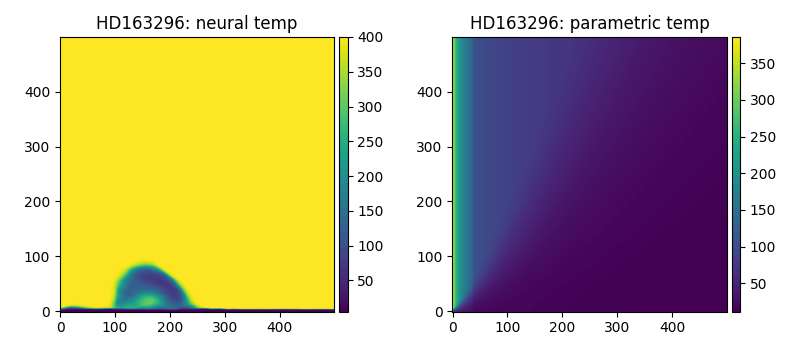

In [10]:
%matplotlib widget
fig, axes = plt.subplots(1, 2, figsize=(8,3.5))
titles = ['{}: neural temp', '{}: parametric temp']
images = [temperature_nn, temperature]
for ax, img, title in zip(axes, images, titles):
    im = ax.imshow(img, origin='lower')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='3%', pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    ax.set_title(title.format(disk_name))
plt.tight_layout()

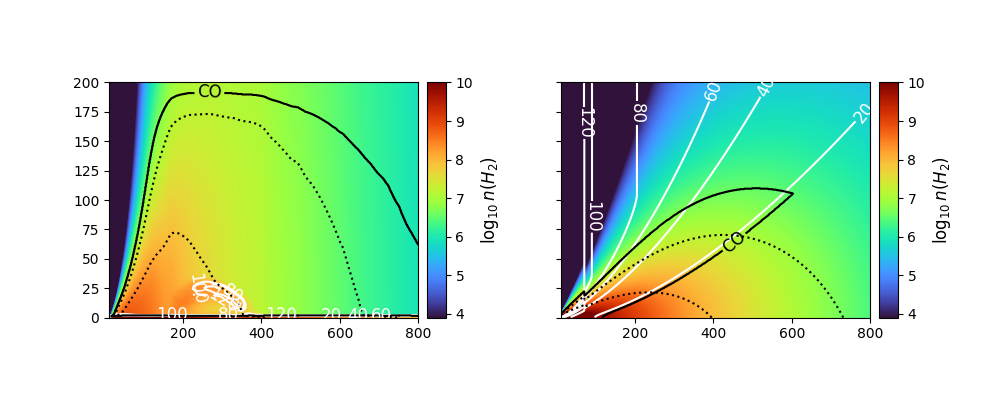

In [9]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2_nn), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature_nn, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co_nn, levels=[disk_params['co_abundance']/2], colors='black')
axes[0].clabel(cp, levels=[disk_params['co_abundance']/2], fmt='CO', inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, sigma_h2_nn, levels=[0.01, 0.1], colors='black', linestyles='dotted')

im = axes[1].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

cp = axes[1].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[1].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[1].contour(r_disk, z_disk, abundance_co, levels=[disk_params['co_abundance']/2], colors='black')
axes[1].clabel(cp, levels=[disk_params['co_abundance']/2], fmt='CO', inline=1, fontsize=12);
cp = axes[1].contour(r_disk, z_disk, sigma_h2, levels=[0.01, 0.1], colors='black', linestyles='dotted')

plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

## MCMC 

In [22]:
import inference 
from inference import DISK_PARAM_INDEX, REV_DISK_PARAM_INDEX
posterior_params = {
    DISK_PARAM_INDEX['co_abundance']: {
        'bounds': [-8, -3],
        'p0_range': [-5, -4],
    }
}

ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
c18o_energy_levels, c18o_radiative_transitions = line_rte.load_molecular_tables(path=c18o_molecular_table)

sampler_dict = inference.create_sampler(
    z_disk=z_disk,
    r_disk=r_disk,
    bbox=bbox_disk,
    pixel_area=pixel_area,
    ray_coords=ray_coords,
    ray_coords_polar=ray_coords_polar,
    obs_dir=obs_dir,
    beam=beam,
    energy_levels=c18o_energy_levels,
    radiative_transitions=c18o_radiative_transitions,
    sigma=0.05,
    disk_params=c18o_disk_params,
    posterior_params=posterior_params,
    stride=None
)

ndim = len(list(posterior_params.keys())) 
nwalkers = 32
nsteps = 100 # Example number of MCMC steps

# Sample initial positions p0 from the param_bounds
p0 = inference.sample_p0(nwalkers, posterior_params, seed=1337)

In [24]:
import emcee
from functools import partial
from network import shard
import jax.scipy as jsp
REV_DISK_PARAM_INDEX = {index: name for name, index in DISK_PARAM_INDEX.items()}
backend = emcee.backends.HDFBackend("mcmc_c18o_abundance_sampler.h5")
backend.reset(nwalkers, ndim)

def logprior(params, sampler_dict):
    """
    Check that 'params' is within the bounds. If so, return 0; else -inf.
    """
    posterior_params = sampler_dict['posterior_params']
    sorted_indices = sorted(posterior_params.keys())

    # uniform prior
    lp = 0.0
    for col, i in enumerate(sorted_indices):
        lo, hi = posterior_params[i]["bounds"]
        in_bounds = jnp.logical_and(params[col] >= lo, params[col] <= hi)
        lp += jnp.where(in_bounds, 0.0, -jnp.inf)
    return lp


def loglikelihood(params, y, freqs, stride, sampler_dict):
    """
    Evaluate the log-likelihood by building the disk model and comparing
    to the data.
    """
    disk_params = sampler_dict['disk_params'].copy()
    posterior_params = sampler_dict['posterior_params']
    sorted_indices = sorted(posterior_params.keys())
    
    # For each col in the 'params' array, figure out which disk param index it corresponds to:
    for col, param_index in enumerate(sorted_indices):
        name = REV_DISK_PARAM_INDEX[param_index]
#         print(f'updated {disk_params[name]} to {params[col]}')
        disk_params[name] = 10**params[col] / 557
        

    # 1) Build temperature field
    temperature = parametric_disk.temperature_profile(
        sampler_dict['z_disk'], sampler_dict['r_disk'], disk_params
    )

    # 2) Build H2 number density
    nd_h2 = parametric_disk.number_density_profile(
        sampler_dict['z_disk'],
        sampler_dict['r_disk'],
        temperature,
        disk_params['gamma'],
        disk_params['r_in'],
        10**disk_params['log_r_c'],
        disk_params['M_gas'],
        disk_params['M_star'],
        disk_params['m_mol']
    )

    # 3) Build velocities
    velocity_az = -parametric_disk.velocity_profile(
        sampler_dict['z_disk'], sampler_dict['r_disk'],
        nd_h2, temperature, disk_params
    )

    # 4) Compute column integrated density N_h2
    N_h2 = parametric_disk.surface_density(sampler_dict['z_disk'], nd_h2)

    # 5) Build the CO abundance
    abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk_params)
    nd_co = abundance_co * nd_h2

    # 6) Interpolate onto ray-coordinates
    gas_nd = grid.interpolate_scalar(
        nd_co, sampler_dict['ray_coords_polar'], sampler_dict['bbox']
    )
    gas_t = grid.interpolate_scalar(
        temperature, sampler_dict['ray_coords_polar'], sampler_dict['bbox'], cval=1e-10
    )
    gas_v_az = grid.interpolate_scalar(
        velocity_az, sampler_dict['ray_coords_polar'], sampler_dict['bbox']
    )
    gas_v = parametric_disk.azimuthal_velocity(sampler_dict['ray_coords'], gas_v_az)

    # 7) Einstein coefficients
    n_up, n_dn = line_rte.n_up_down(
        gas_nd,
        gas_t,
        sampler_dict['energy_levels'],
        sampler_dict['radiative_transitions'],
        transition=disk_params['transition']
    )
    alpha_tot = line_rte.alpha_total_co(disk_params['v_turb'], gas_t)

    # 8) Compute the model data cube
    model_cube = line_rte.compute_spectral_cube_pmap(
        shard(freqs), gas_v, alpha_tot, n_up, n_dn,
        sampler_dict['a_ud'], sampler_dict['b_ud'], sampler_dict['b_du'],
        sampler_dict['ray_coords'], sampler_dict['obs_dir'],
        sampler_dict['nu0'], sampler_dict['pixel_area']
    )

    # 9) Convolve model with the beam
    model_cube = jnp.nan_to_num(model_cube).reshape(freqs.size, *sampler_dict['ray_coords'].shape[:2])
    model_cube = sensor.fftconvolve_vmap(model_cube, sampler_dict['beam'])

    # 10) Evaluate log-likelihood
    if stride is not None:
        model_cube = model_cube[:, ::stride, ::stride]
        y = y[:, ::stride, ::stride]

    sigma = sampler_dict['sigma']
    logpdf = jsp.stats.norm.logpdf(y, model_cube, sigma)
    return jnp.sum(logpdf)

@partial(jax.jit, static_argnames=['stride']) # TODO: seperate static components from sampler_dict to seperate arg
def logprob(params, y, freqs, sampler_dict, stride=None):
    """
    jitted version for logprior + loglikelihood.
    """
    return logprior(params, sampler_dict) + loglikelihood(params, y, freqs, stride, sampler_dict)

def logprob_wrapper(params):
    return logprob(params, c18o_data, c18o_freqs, sampler_dict)

sampler = emcee.EnsembleSampler(
    nwalkers=nwalkers,
    ndim=ndim,
    log_prob_fn=logprob_wrapper,
    backend=backend
)

print("Running MCMC...")
sampler.run_mcmc(p0, nsteps, progress=True);

Running MCMC...


100%|████████████████████████████████████████████████████████████████████████████████████| 100/100 [06:27<00:00,  3.88s/it]


State([[-4.78164469]
 [-4.78924077]
 [-4.78299092]
 [-4.78373994]
 [-4.78462914]
 [-4.7913286 ]
 [-4.78707294]
 [-4.78567066]
 [-4.78858222]
 [-4.78572163]
 [-4.78514188]
 [-4.79167602]
 [-4.781223  ]
 [-4.79144597]
 [-4.78131866]
 [-4.78464551]
 [-4.78675481]
 [-4.78348153]
 [-4.79112639]
 [-4.78705393]
 [-4.77992923]
 [-4.78659843]
 [-4.78079041]
 [-4.78269773]
 [-4.78586711]
 [-4.78137084]
 [-4.78088569]
 [-4.78541112]
 [-4.78931056]
 [-4.78215736]
 [-4.78821093]
 [-4.78495368]], log_prob=[3961894.74371547 3961894.91664217 3961895.14504257 3961895.29883862
 3961895.41707492 3961894.0874621  3961895.3837854  3961895.46703123
 3961895.10191561 3961895.46702759 3961895.4535971  3961893.91552227
 3961894.58503131 3961894.03054354 3961894.62240493 3961895.41859789
 3961895.41778659 3961895.25138505 3961894.18272486 3961895.38606585
 3961893.99956971 3961895.4312518  3961894.40587063 3961895.07132222
 3961895.46576132 3961894.64244747 3961894.44676205 3961895.46350995
 3961894.89479575 39

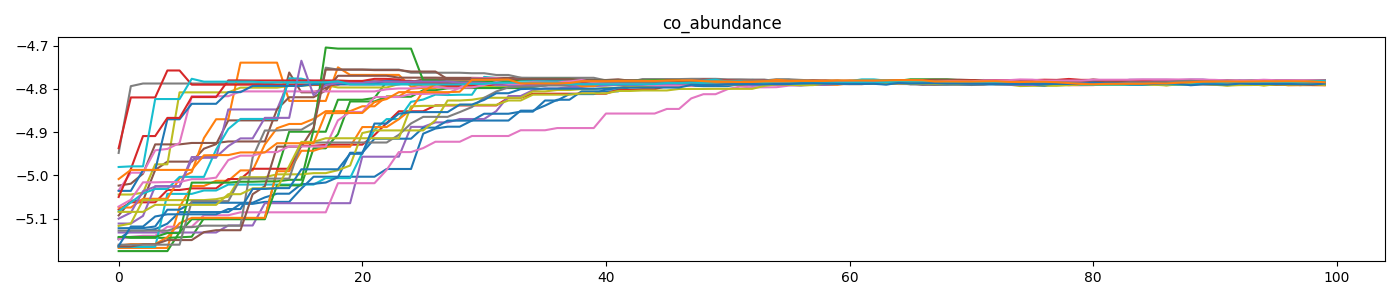

In [25]:
chain = sampler.get_chain()

ndim = chain.shape[-1]
param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

%matplotlib notebook
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes.plot(chain[...,i])
    axes.set_title(param_labels[i])

plt.tight_layout()

flat_samples = sampler.get_chain(discard=60, thin=1, flat=True)
print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)

p16, p50, p84 = np.percentile(flat_samples[:, i], [16, 50, 84])
median_val = p50
minus_err = p50 - p16
plus_err  = p84 - p50
print(f"{'log_co_abundance':8s}: {median_val:.3f} +{plus_err:.3f} -{minus_err:.3f}")

In [55]:
"""
Notes
-----
Flaherty et al. 2017 (https://iopscience.iop.org/article/10.3847/1538-4357/aa79f9/pdf) leave the CO/H2 abundance variable with MCMC value of 10**(-4.610)
Other variables that change due to MCMC of the specific dataset are:
    'v_turb': 0.05,
    'gamma': 0.62,
    'r_in': 35.6,
    'r_break': 102,
    'q_in': -1.4,
"""
c18o_molecular_table = "../molecular_tables/molecule_12c18o.inp"
c18o_disk_params = {**disk_params, 'co_abundance': 10**(-4.610) * c18o_abundance}
c18o_disk_params_flaherty = {**disk_params, 'co_abundance': 10**(-4.610) * c18o_abundance} 


# Compute the relative abundance of co
abundance_c18o = parametric_disk.co_abundance_profile(N_h2, temperature, c18o_disk_params_flaherty)
c18o_nd_co = abundance_c18o * nd_h2

abundance_c18o_nn = parametric_disk.co_abundance_profile(N_h2_nn, temperature_nn, c18o_disk_params)
c18o_nd_co_nn = abundance_c18o_nn * nd_h2_nn

In [56]:
# Render spectral cube and convolve with gaussian beam
c18o_images = render_cube(
    ray_coords,
    pixel_area,
    c18o_disk_params_flaherty,
    c18o_nd_co,
    temperature,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=c18o_freqs,
    nu0=c18o_nu0,
    obs_dir=obs_dir,
    molecular_table=c18o_molecular_table
)
c18o_images_nn = render_cube(
    ray_coords,
    pixel_area,
    c18o_disk_params,
    c18o_nd_co_nn,
    temperature_nn,
    -velocity_az_nn,  # note sign convention
    bbox_disk,
    freqs=c18o_freqs,
    nu0=c18o_nu0,
    obs_dir=obs_dir,
    molecular_table=c18o_molecular_table
)

c18o_images_blurred = sensor.fftconvolve_vmap(c18o_images, c18o_beam)
c18o_images_blurred_nn = sensor.fftconvolve_vmap(c18o_images_nn, c18o_beam)

computing pinhole spectral cube for a total of 24 frequencies
computing pinhole spectral cube for a total of 24 frequencies


interactive(children=(IntSlider(value=11, description='frame', max=23), Output()), _dom_classes=('widget-inter…

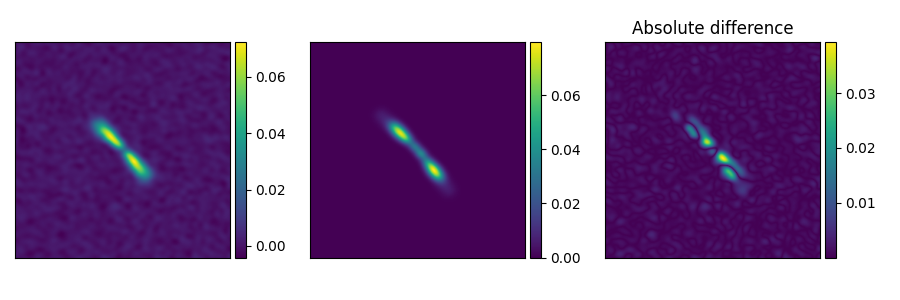

In [57]:
%matplotlib widget
visualization.slider_frame_comparison(c18o_data, c18o_images_blurred_nn)

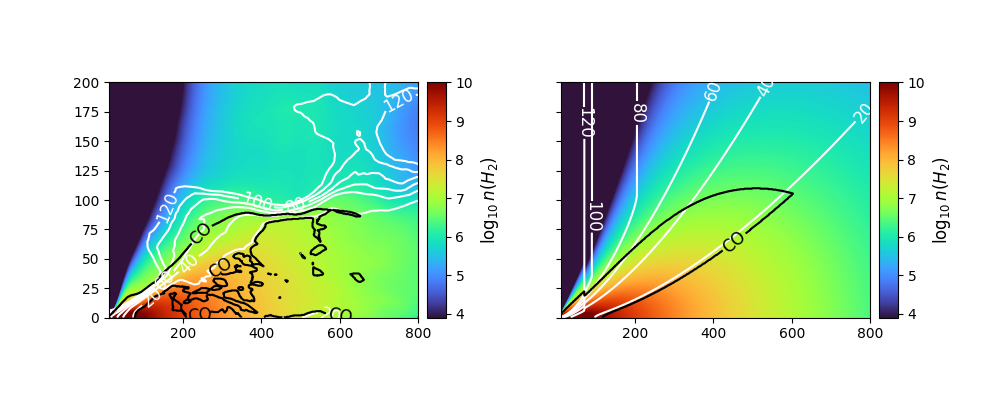

In [44]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2_nn), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature_nn, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_co_nn, levels=[disk_params['co_abundance']/2], colors='black')
axes[0].clabel(cp, levels=[disk_params['co_abundance']/2], fmt='CO', inline=1, fontsize=12);

im = axes[1].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

cp = axes[1].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[1].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[1].contour(r_disk, z_disk, abundance_co, levels=[disk_params['co_abundance']/2], colors='black')
axes[1].clabel(cp, levels=[disk_params['co_abundance']/2], fmt='CO', inline=1, fontsize=12);

plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

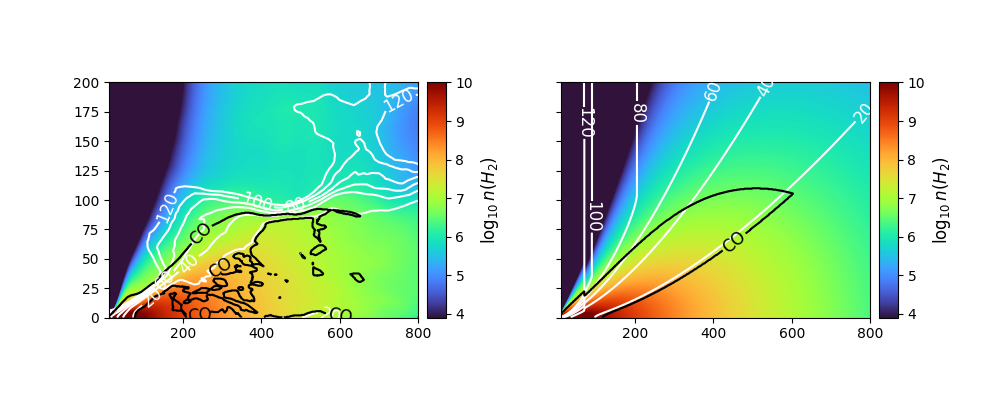

In [43]:
%matplotlib widget
fig, axes = plt.subplots(1,2, figsize=(10,4), sharey=True)
im = axes[0].imshow(np.log10(nd_h2_nn), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[0])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

levels = [20, 40, 60, 80, 100, 120]
cp = axes[0].contour(r_disk, z_disk, temperature_nn, levels, colors='white')
axes[0].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[0].contour(r_disk, z_disk, abundance_c18o_nn, levels=[c18o_disk_params['co_abundance']/2], colors='black')
axes[0].clabel(cp, levels=[c18o_disk_params['co_abundance']/2], fmt='CO', inline=1, fontsize=12);

im = axes[1].imshow(np.log10(nd_h2), origin='lower', cmap='turbo', extent=[r_disk.min(), r_disk.max(), z_disk.min(), z_disk.max()], vmin=3.9, vmax=10, aspect=3);
divider = make_axes_locatable(axes[1])
cax = divider.append_axes('right', size='2%', pad=-3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r'$\log_{10} n(H_2)$', fontsize=12)

cp = axes[1].contour(r_disk, z_disk, temperature, levels, colors='white')
axes[1].clabel(cp, levels, inline=1, fontsize=12);
cp = axes[1].contour(r_disk, z_disk, abundance_c18o, levels=[c18o_disk_params_flaherty['co_abundance']/2], colors='black')
axes[1].clabel(cp, levels=[c18o_disk_params_flaherty['co_abundance']/2], fmt='CO', inline=1, fontsize=12);

plt.tight_layout()
fig.subplots_adjust(left=-0.2, wspace=-0.3)

interactive(children=(IntSlider(value=11, description='frame', max=23), Output()), _dom_classes=('widget-inter…

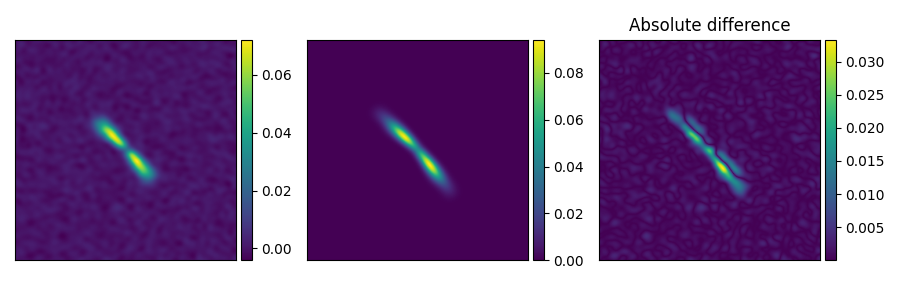

In [48]:
%matplotlib widget
visualization.slider_frame_comparison(c18o_data, c18o_images_blurred)

interactive(children=(IntSlider(value=11, description='frame', max=23), Output()), _dom_classes=('widget-inter…

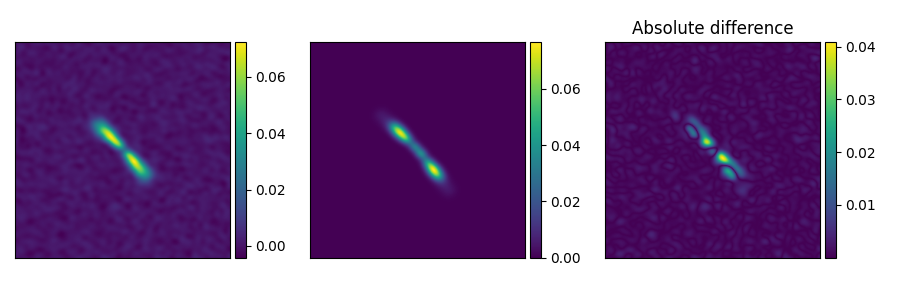

In [49]:
%matplotlib widget
visualization.slider_frame_comparison(c18o_data, c18o_images_blurred_nn)

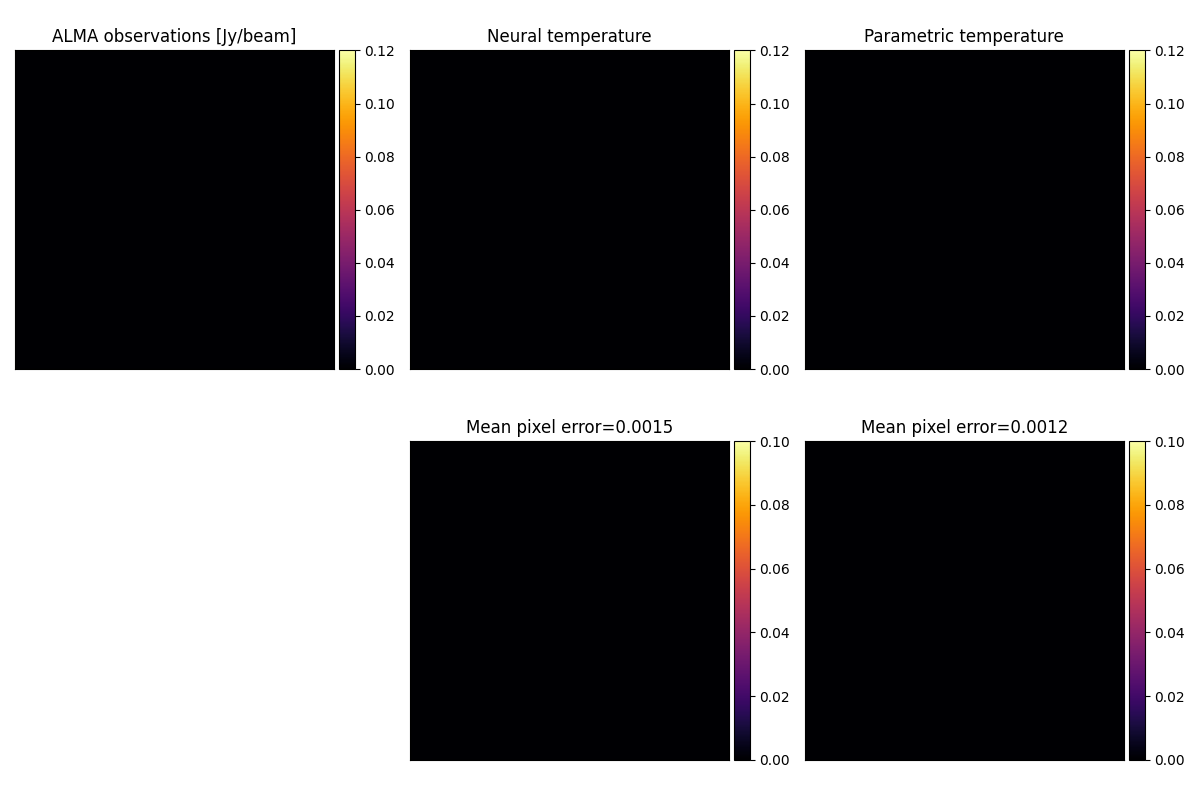

In [40]:
%matplotlib widget
output = checkpoint_dir.joinpath('spectral_cubes_comparison_iter30000_c18o_valiation.gif')

# Save a gif/plot for the data cube for quick visualization
%matplotlib widget
fig, axes = plt.subplots(2,3,figsize=(12,8))
axes[1,0].axis("off")
axes_list = list(axes[0]) + list(axes[1,1:])

c18o_data_fit = np.abs(c18o_data - c18o_images_blurred).mean()
c18o_data_fit_nn = np.abs(c18o_data - c18o_images_blurred_nn).mean()
titles = [r'ALMA observations [Jy/beam]', 'Neural temperature', 'Parametric temperature',
          r'Mean pixel error={:1.4f}'.format(c18o_data_fit_nn), r'Mean pixel error={:1.4f}'.format(c18o_data_fit)]
c18o_movies = [c18o_data, np.array(c18o_images_blurred_nn), np.array(c18o_images_blurred),
                np.abs(c18o_data - c18o_images_blurred_nn), np.abs(c18o_data - c18o_images_blurred)]
visualization.animate_movies_synced(
    c18o_movies, axes_list, vmin=[0,0,0,0,0,0], vmax=[0.12,0.12,0.12,0.1,0.1], 
    titles=titles, cmaps='inferno', fps=3, writer='ffmpeg', #output=output
)